In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import statsmodels.api as sm #ARIMAX - https://people.duke.edu/~rnau/411arim.htm?utm_source=copilot.com # I plan to use p and q max of 5 based on the defaults in the r package auto.arima (https://pkg.robjhyndman.com/forecast/reference/auto.arima.html?utm_source=copilot.com)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import threading
from datetime import datetime
import pmdarima as pm
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import json

In [2]:
warnings.simplefilter('ignore', ValueWarning)
#warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore')

In [3]:
# Preset alpha value for the Bernferroni correction
alpha = 0.05

In [4]:
# Parent directory for data loading
parent_dir = Path.cwd().parent.parent

In [5]:
# Import datasets and drop any nulls for clean processing
final_gig_m_df = pd.read_csv(os.path.join(parent_dir, 'data', 'final', 'gig_monthly_data.csv')).dropna().reset_index(drop=True)
final_sp500_m_df = pd.read_csv(os.path.join(parent_dir, 'data', 'final', 'sp500_monthly_data.csv')).dropna().reset_index(drop=True)

In [6]:
# See correlation_analysis_for_regression.ipynb for how these columns were selected
# Partially based on correlation and partially based on an understanding of the different meanings behind economic indicators
columns_to_keep = ['cpi_data_monthly', # SA
'rec_smooth_prob_data_monthly', # NSA -- but I don't think recessions are seasonal
'unemployment_data_monthly', # SA
'interest_rate_mtg_data_weekly', # NSA
'consumer_sentiment_data_monthly', # NSA
#'Ticker',
'date',
'target'#, # Normalized by dividing closing price with cpi
]

In [7]:
# Reduce datasets to only use columns to keep and set date as index
#final_gig_m_df.set_index('date', inplace=True)
final_gig_m_df = final_gig_m_df[columns_to_keep]
#final_sp500_m_df.set_index('date', inplace=True)
final_sp500_m_df = final_sp500_m_df[columns_to_keep]

In [8]:
final_gig_m_df = final_gig_m_df.groupby(['date'
                        ,'cpi_data_monthly'
                        ,'rec_smooth_prob_data_monthly'
                        ,'unemployment_data_monthly'
                        ,'interest_rate_mtg_data_weekly'
                        ,'consumer_sentiment_data_monthly']).sum('target')
scaler = MinMaxScaler()
final_gig_m_df['target'] = scaler.fit_transform(final_gig_m_df['target'].to_frame())
final_gig_m_df.reset_index(inplace=True)
final_gig_m_df['date'] = pd.to_datetime(final_gig_m_df['date'])
final_gig_m_df.set_index('date', inplace=True)
#final_gig_m_df['target'] = np.log(final_gig_m_df['target'])

final_sp500_m_df = final_sp500_m_df.groupby(['date'
                        ,'cpi_data_monthly'
                        ,'rec_smooth_prob_data_monthly'
                        ,'unemployment_data_monthly'
                        ,'interest_rate_mtg_data_weekly'
                        ,'consumer_sentiment_data_monthly']).sum('target')
scaler = MinMaxScaler()
final_sp500_m_df['target'] = scaler.fit_transform(final_sp500_m_df['target'].to_frame())
final_sp500_m_df.reset_index(inplace=True)
final_sp500_m_df['date'] = pd.to_datetime(final_sp500_m_df['date'])
final_sp500_m_df.set_index('date', inplace=True)
#final_sp500_m_df['target'] = np.log(final_sp500_m_df['target'])

In [9]:
final_sp500_m_df

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
date,,,,,,
2010-01-01,217.488,0.10,9.8,5.0300,74.4,0.000000
2010-02-01,217.281,0.12,9.8,4.9900,73.6,0.007354
2010-03-01,217.353,0.06,9.9,4.9675,73.6,0.019488
2010-04-01,217.403,0.06,9.9,5.0980,72.2,0.025925
2010-05-01,217.290,0.06,9.6,4.8875,73.6,0.011932
...,...,...,...,...,...,...
2023-09-01,307.276,0.42,3.7,7.2000,67.8,0.814582
2023-10-01,307.696,0.60,3.9,7.6200,63.8,0.776102
2023-11-01,308.148,0.62,3.7,7.4420,61.3,0.873884


In [10]:
# # Further normalize by stock ticker in both dataframes in order to get more accurate weights
# for idx, ticker in enumerate(final_gig_m_df['Ticker'].unique()):
#     scaler = MinMaxScaler()
#     if idx == 0:
#         new_final_gig_m_df = final_gig_m_df[final_gig_m_df['Ticker']==ticker]
#         scaler.fit(new_final_gig_m_df['target'].to_frame())
#         new_final_gig_m_df['target'] = scaler.transform(new_final_gig_m_df['target'].to_frame())
#     else:
#         new_df = final_gig_m_df[final_gig_m_df['Ticker']==ticker]
#         scaler.fit(new_df['target'].to_frame())
#         new_df['target'] = scaler.transform(new_df['target'].to_frame())
#         new_final_gig_m_df = pd.concat([new_final_gig_m_df, new_df])
# final_gig_m_df = new_final_gig_m_df.copy()
# final_gig_m_df.sort_values('date', inplace=True)
# final_gig_m_df.set_index('date', inplace=True)
# final_gig_m_df.drop('Ticker', axis=1, inplace=True)
# #final_gig_m_df.drop(['date', 'Ticker'], axis=1)

# for idx, ticker in enumerate(final_sp500_m_df['Ticker'].unique()):
#     scaler = MinMaxScaler()
#     if idx == 0:
#         new_final_sp500_m_df = final_sp500_m_df[final_sp500_m_df['Ticker']==ticker]
#         scaler.fit(new_final_sp500_m_df['target'].to_frame())
#         new_final_sp500_m_df['target'] = scaler.transform(new_final_sp500_m_df['target'].to_frame())
#     else:
#         new_df = final_sp500_m_df[final_sp500_m_df['Ticker']==ticker]
#         scaler.fit(new_df['target'].to_frame())
#         new_df['target'] = scaler.transform(new_df['target'].to_frame())
#         new_final_sp500_m_df = pd.concat([new_final_sp500_m_df, new_df])
# final_sp500_m_df = new_final_sp500_m_df.copy()
# final_sp500_m_df.sort_values('date', inplace=True)
# final_sp500_m_df.set_index('date', inplace=True)
# final_sp500_m_df.drop('Ticker', axis=1, inplace=True)
# #final_sp500_m_df.drop(['date', 'Ticker'], axis=1)
# final_sp500_m_df

In [11]:
# Modifying to remove ticker and date
columns_to_keep = ['cpi_data_monthly', # SA
'rec_smooth_prob_data_monthly', # NSA -- but I don't think recessions are seasonal
'unemployment_data_monthly', # SA
'interest_rate_mtg_data_weekly', # NSA
'consumer_sentiment_data_monthly', # NSA
'target'#, # Normalized by dividing closing price with cpi
]

In [12]:
# In order to run the ARIMAX regression, I need to check for stationarity among all variables, including the endogenous variable (target)
# Interpreting the Results - Taken from (https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/)
# - ADF Statistic: If it's significantly lower than the critical values, reject the null.
# - p-value: If p < 0.05, the series is likely stationary.
# - Critical Values: Used for comparing with the ADF statistic.
# To fix it, we will be running the diff function on the column per https://www.geeksforgeeks.org/machine-learning/time-series-data-transformation-using-python/

# Gig
for col in columns_to_keep:

    adf = sm.tsa.stattools.adfuller(final_gig_m_df[col])
    adf_dict = {'type':'gig','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
    print(adf_dict)

    if adf_dict['p-value'] > alpha \
            and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
        
        final_gig_m_df[col] = final_gig_m_df[col].diff()
        final_gig_m_df.dropna(inplace=True)

        adf = sm.tsa.stattools.adfuller(final_gig_m_df[col])
        adf_dict = {'type':'gig','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
        print(adf_dict)

        if adf_dict['p-value'] > alpha \
                and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
            
            print(f'{col} is broke!')

# SP500
for col in columns_to_keep:

    adf = sm.tsa.stattools.adfuller(final_sp500_m_df[col])
    adf_dict = {'type':'sp500','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
    print(adf_dict)

    if adf_dict['p-value'] > alpha \
            and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
        
        final_sp500_m_df[col] = final_sp500_m_df[col].diff()
        final_sp500_m_df.dropna(inplace=True)

        adf = sm.tsa.stattools.adfuller(final_sp500_m_df[col])
        adf_dict = {'type':'sp500','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
        print(adf_dict)

        if adf_dict['p-value'] > alpha \
                and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
            
            print(f'{col} is broke!')

{'type': 'gig', 'column': 'cpi_data_monthly', 'adf-score': np.float64(0.7936483542054812), 'p-value': np.float64(0.9915329456743927), 'critical-values': {'1%': np.float64(-3.471633386932248), '5%': np.float64(-2.8796651107461972), '10%': np.float64(-2.576433647235832)}}
{'type': 'gig', 'column': 'cpi_data_monthly', 'adf-score': np.float64(-2.326389309791294), 'p-value': np.float64(0.16359807733961318), 'critical-values': {'1%': np.float64(-3.471633386932248), '5%': np.float64(-2.8796651107461972), '10%': np.float64(-2.576433647235832)}}
cpi_data_monthly is broke!
{'type': 'gig', 'column': 'rec_smooth_prob_data_monthly', 'adf-score': np.float64(-4.456644645979195), 'p-value': np.float64(0.0002353230314046225), 'critical-values': {'1%': np.float64(-3.4718957209472654), '5%': np.float64(-2.8797795410156253), '10%': np.float64(-2.5764947265625)}}
{'type': 'gig', 'column': 'unemployment_data_monthly', 'adf-score': np.float64(-2.7492752316655005), 'p-value': np.float64(0.06589268253207793), 

In [13]:
final_gig_m_df.describe()

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,0.559364,1.708727,5.815152,0.009361,0.041212,0.002593
std,0.731989,10.934414,2.204475,0.195372,4.255914,0.035813
min,-2.044000,0.000000,3.400000,-0.627000,-17.300000,-0.151292
25%,0.159000,0.140000,3.900000,-0.106000,-2.200000,-0.006492
50%,0.521000,0.280000,5.100000,-0.016000,0.400000,0.002009
75%,0.779000,0.680000,7.500000,0.064000,2.900000,0.011460
max,3.659000,100.000000,14.800000,0.889500,9.300000,0.146648


In [14]:
final_sp500_m_df.describe()

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,0.559364,1.708727,5.815152,0.009361,0.041212,0.005569
std,0.731989,10.934414,2.204475,0.195372,4.255914,0.032381
min,-2.044000,0.000000,3.400000,-0.627000,-17.300000,-0.110927
25%,0.159000,0.140000,3.900000,-0.106000,-2.200000,-0.004955
50%,0.521000,0.280000,5.100000,-0.016000,0.400000,0.005543
75%,0.779000,0.680000,7.500000,0.064000,2.900000,0.018284
max,3.659000,100.000000,14.800000,0.889500,9.300000,0.097781


In [15]:
# Get all possible combinations of exogenous variables for the regression analysis
# Since both datasets have the same columns, we can just use the columns from one of them to get the combinations
exog_cols = []
for c in final_gig_m_df.columns:
    temp_cols = []
    if c != 'target':
        temp_cols.append(c)
        for c2 in final_gig_m_df.columns:
            if c2 != 'target' and c2 != c:
                temp_cols.append(c2)
                temp_col_set = frozenset(sorted(temp_cols))
                exog_cols.append(temp_col_set)
exog_cols = frozenset(exog_cols)
exog_cols = [sorted(i) for i in exog_cols]

In [16]:
# Modify the alpha to use the bonferroni correction since we are testing many combinations
bonferroni_alpha = alpha / len(exog_cols)

In [17]:
def _get_result_dict(fitted_model, exog_cols, exog_idx):

    #print(fitted_model.summary())
    model_results ={
        # "columns": str(fitted_model.model.exog_names),
        "model_summary": [{}],
        #"log_liklihood": [float(fitted_model.llf)],
        # "aic": [float(fitted_model.aic)],
        # "bic": [float(fitted_model.bic)],
        # "hqic": [float(fitted_model.hqic)],
        }

    for row in fitted_model.summary().tables[0].data:
        for idx, val in enumerate(row):
            if isinstance(val, str) and 'Log Likelihood' in val:
                model_results['log_likelihood'] = [float(row[idx+1])]
            elif isinstance(val, str) and  'AIC' in val:
                model_results['aic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'BIC' in val:
                model_results['bic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'HQIC' in val:
                model_results['hqic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'Model:' in val:
                model_results['model'] = [row[idx+1]]
                for s in model_results['model'][0].split(','):
                    if 'SARIMAX' in s:
                        model_results['p'] = ''
                        model_results['d'] = ''
                        model_results['q'] = ''
                    elif 'ARIMAX(' in s:
                        model_results['p'] = [int(s[7].strip())]
                    elif ')' in s:
                        model_results['q'] = [int(s.strip()[0])]
                    else:
                        model_results['d'] = [int(s.strip())]

    for i, row in enumerate(fitted_model.summary().tables[1].data):
        if i > 0:
            for idx, val in enumerate(row):
                if idx == 0:
                    name = val.strip()
                    model_results['model_summary'][0][name] = {} 
                elif idx == 1:
                    model_results['model_summary'][0][name]['std_err'] = [float(val.strip())]
                elif idx == 2:
                    model_results['model_summary'][0][name]['coef'] = [float(val.strip())]
                elif idx == 3:
                    model_results['model_summary'][0][name]['z'] = [float(val.strip())]
                elif idx == 4:
                    model_results['model_summary'][0][name]['p>|z|'] = [float(val.strip())]
                elif idx == 5:
                    model_results['model_summary'][0][name]['ci'] = [float(val.strip())]
                elif idx == 6:
                    model_results['model_summary'][0][name]['ci'].append(float(val.strip()))

    for row in fitted_model.summary().tables[2].data:
        for idx, val in enumerate(row):
            if "Ljung" in val:
                model_results["ljung_box"] = [float(row[idx+1])]
            elif "Durbin-Watson" in val:
                model_results["durbin_watson"] = [float(row[idx+1])]
            elif "Prob(Q)" in val:
                model_results["prob"] = [float(row[idx+1])]
            elif "Heteroskedasticity" in val:
                model_results["heteroskedasticity"] = [float(row[idx+1])]
            elif "Prob(H)" in val:
                model_results["heteroskedasticity_prob"] = [float(row[idx+1])]
            elif "Jarque-Bera" in val:
                model_results["jarque_bera"] = [float(row[idx+1])]
            elif "Prob(JB)" in val:
                model_results["jarque_bera_prob"] = [float(row[idx+1])]
            elif "Skew" in val:
                model_results["skew"] = [float(row[idx+1])]
            elif "Kurtosis" in val:
                model_results["kurtosis"] = [float(row[idx+1])]
            elif "Cond." in val:
                model_results["cond_no"] = [float(row[idx+1])]
    
    model_df = pd.DataFrame.from_dict(model_results, orient='columns')
    model_df['exog_cols']= [exog_cols]
    model_df['exog_idx'] = [exog_idx]
    return model_df

In [18]:
def _get_model(type, endog, exog, check_managed_list, total_managed_list, exog_idx):
    print(f"Type: {type}, Thread {threading.current_thread().name} started for exogenous variable index {exog_idx}...")
    # Run regression analysis for gig dataset
    model = pm.auto_arima(endog, seasonal=False, stationary=True, stepwise=True, max_p=12, max_q=12, random_state=42)
    results = model.fit(endog, exog)
    result_dict = _get_result_dict(results, list(exog.columns), exog_idx)
    new_aic, new_bic = float(results.aic()), float(results.bic())
    result_tuple = (new_aic, new_bic, results, exog_idx)
    check_managed_list.append([exog_idx, results])
    total_managed_list.append(result_dict)
    print(f"Type: {type}, Thread {threading.current_thread().name} for exogenous variable index {exog_idx} finished!")
    return 200

In [19]:
# # Run ARIMAX regression analysis for each combination of exogenous variables and iterate over the different p and q values (0-5) to find the best model based on AIC/BIC for each column combination
#     # Specifically, we want to minimize the AIC/BIC per https://fastercapital.com/content/Bayesian-Information-Criterion--BIC---AIC-vs-BIC--Navigating-the-Waters-of-Statistical-Criteria.html
# # d is set to 0 since we already made the data stationary in the previous step

# for exog_col in exog_cols:
    
#     gig_aic, gig_bic = 1000000, 1000000
#     sp500_aic, sp500_bic = 1000000, 1000000

#     for p in range(0,6):
#         for q in range(0,6):

#             # Run regression analysis for gig dataset
#             model_gig = sm.tsa.statespace.SARIMAX(final_gig_m_df['target'], exog=final_gig_m_df[exog_col], order=(p,0,q))
#             results_gig = model_gig.fit()
#             gig_new_aic, gig_new_bic = float(results_gig.aic), float(results_gig.bic)
#             if gig_new_aic < gig_aic:
#                 if gig_new_bic < gig_bic:
#                     print("(gig) Uh oh, BIC is bad!")
#                 gig_aic, gig_bic = gig_new_aic, gig_new_bic
#                 use_gig_result = results_gig
#             elif gig_new_aic == gig_aic and gig_new_bic < gig_bic:
#                 print("(gig) AIC is equal but BIC is lower!")
#                 gig_aic, gig_bic = gig_new_aic, gig_new_bic
#                 use_gig_result = results_gig
#             else:
#                 continue

#             # Run regression analysis for sp500 dataset
#             model_sp500 = sm.tsa.statespace.SARIMAX(final_sp500_m_df['target'], exog=final_sp500_m_df[exog_col], order=(p,0,q))
#             results_sp500 = model_sp500.fit()
#             sp500_new_aic, sp500_new_bic = float(results_sp500.aic), float(results_sp500.bic)
#             if sp500_new_aic < sp500_aic:
#                 if sp500_new_bic < sp500_bic:
#                     print("(sp500) Uh oh, BIC is bad!")
#                 sp500_aic, sp500_bic = sp500_new_aic, sp500_new_bic
#                 use_sp500_result = results_sp500
#             elif sp500_new_aic == sp500_aic and sp500_new_bic < sp500_bic:
#                 print("(sp500) AIC is equal but BIC is lower!")
#                 sp500_aic, sp500_bic = sp500_new_aic, sp500_new_bic
#                 use_sp500_result = results_sp500
#             else:
#                 continue
    
#     if 'gig_model_df' in globals() and 'sp500_model_df' in globals():
#         gig_model_df = pd.concat([gig_model_df, _get_result_dict(results_gig)], ignore_index=True)
#         sp500_model_df = pd.concat([sp500_model_df, _get_result_dict(results_sp500)], ignore_index=True)
#     else:
#         gig_model_df = _get_result_dict(use_gig_result)
#         sp500_model_df = _get_result_dict(use_sp500_result)


In [20]:
best_gig_model_lst = multiprocessing.Manager().list()
total_gig_model_lst = multiprocessing.Manager().list()
best_sp500_model_lst = multiprocessing.Manager().list()
total_sp500_model_lst = multiprocessing.Manager().list()

with ThreadPoolExecutor(max_workers=20) as executor:
    for idx, exog_col in enumerate(exog_cols):
                future = executor.submit(_get_model, 'gig', final_gig_m_df['target'], final_gig_m_df[exog_col], best_gig_model_lst, total_gig_model_lst, idx)
                future = executor.submit(_get_model, 'sp500', final_sp500_m_df['target'], final_sp500_m_df[exog_col], best_sp500_model_lst, total_sp500_model_lst, idx)

print(f"\nLength of best_gig_model_df_lst: {len(total_gig_model_lst)}")
print(f"Length of best_sp500_model_df_lst: {len(total_sp500_model_lst)}")

Type: gig, Thread ThreadPoolExecutor-0_0 started for exogenous variable index 0...
Type: sp500, Thread ThreadPoolExecutor-0_1 started for exogenous variable index 0...
Type: gig, Thread ThreadPoolExecutor-0_2 started for exogenous variable index 1...
Type: sp500, Thread ThreadPoolExecutor-0_3 started for exogenous variable index 1...
Type: gig, Thread ThreadPoolExecutor-0_4 started for exogenous variable index 2...
Type: sp500, Thread ThreadPoolExecutor-0_5 started for exogenous variable index 2...
Type: gig, Thread ThreadPoolExecutor-0_6 started for exogenous variable index 3...
Type: sp500, Thread ThreadPoolExecutor-0_7 started for exogenous variable index 3...
Type: gig, Thread ThreadPoolExecutor-0_8 started for exogenous variable index 4...
Type: sp500, Thread ThreadPoolExecutor-0_9 started for exogenous variable index 4...
Type: gig, Thread ThreadPoolExecutor-0_10 started for exogenous variable index 5...
Type: sp500, Thread ThreadPoolExecutor-0_11 started for exogenous variable i

In [21]:
for idx, item in enumerate(total_gig_model_lst):
    if idx == 0:
        first_df = item
    elif idx == 1:
        gig_model_df = pd.concat([first_df, item]) 
    else:
        gig_model_df = pd.concat([gig_model_df, item])
gig_model_df.sort_values('aic', inplace=True)

for idx, item in enumerate(total_sp500_model_lst):
    if idx == 0:
        first_df = item
    elif idx == 1:
        sp500_model_df = pd.concat([first_df, item]) 
    else:
        sp500_model_df = pd.concat([sp500_model_df, item])
sp500_model_df.sort_values('aic', inplace=True)

In [22]:
# endog = final_gig_m_df['target']
# exog = final_gig_m_df[exog_cols[0]]
# check_managed_list = []
# total_managed_list = []
# exog_idx = 0
# type = 'gig'
# _get_model(type, endog, exog, check_managed_list, total_managed_list, exog_idx)
# # model = pm.auto_arima(endog, seasonal=False, stationary=True, stepwise=True)
# # results = model.fit(endog, exog)
# # results.summary().tables[1].data

In [23]:
gig_model_df#['model_summary'].iloc[0]
# 9 was best and 6 was worst before I changed how I do differencing
# 4 is best and 8 is worst with new differencing

,model_summary,model,p,d,q,log_likelihood,aic,bic,hqic,ljung_box,jarque_bera,prob,jarque_bera_prob,heteroskedasticity,skew,heteroskedasticity_prob,kurtosis,exog_cols,exog_idx
0,"{'cpi_data_monthly': {'std_err': [0.0012], 'co...","SARIMAX(0, 0, 2)",,0,2,329.548,-649.097,-633.567,-642.793,0.05,177.25,0.83,0.0,13.42,0.43,0.0,8.01,"[cpi_data_monthly, interest_rate_mtg_data_weekly]",8
0,"{'cpi_data_monthly': {'std_err': [-0.0022], 'c...","SARIMAX(0, 0, 2)",,0,2,331.170,-648.340,-626.598,-639.514,0.05,158.50,0.81,0.0,11.29,0.46,0.0,7.71,"[cpi_data_monthly, interest_rate_mtg_data_week...",2
0,"{'cpi_data_monthly': {'std_err': [0.0012], 'co...","SARIMAX(0, 0, 2)",,0,2,329.522,-647.043,-628.408,-639.479,0.03,157.51,0.87,0.0,13.58,0.36,0.0,7.73,"[cpi_data_monthly, interest_rate_mtg_data_week...",3
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,330.969,-645.938,-621.090,-635.851,0.09,155.47,0.77,0.0,11.29,0.49,0.0,7.65,"[consumer_sentiment_data_monthly, cpi_data_mon...",7
0,"{'cpi_data_monthly': {'std_err': [-0.0051], 'c...","SARIMAX(0, 0, 2)",,0,2,327.325,-644.649,-629.120,-638.345,0.05,184.55,0.82,0.0,14.84,0.30,0.0,8.15,"[cpi_data_monthly, unemployment_data_monthly]",6
0,"{'cpi_data_monthly': {'std_err': [-0.0057], 'c...","SARIMAX(0, 0, 2)",,0,2,327.352,-642.705,-624.069,-635.140,0.07,191.63,0.80,0.0,14.48,0.36,0.0,8.23,"[cpi_data_monthly, rec_smooth_prob_data_monthl...",1
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,327.076,-640.152,-618.410,-631.326,0.25,190.07,0.62,0.0,14.64,0.39,0.0,8.20,"[consumer_sentiment_data_monthly, cpi_data_mon...",4
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,325.045,-640.090,-624.560,-633.786,0.05,201.64,0.82,0.0,18.42,0.27,0.0,8.39,"[consumer_sentiment_data_monthly, cpi_data_mon...",9
0,"{'cpi_data_monthly': {'std_err': [-0.0016], 'c...","SARIMAX(0, 0, 2)",,0,2,324.868,-639.736,-624.207,-633.432,0.14,198.19,0.71,0.0,19.52,0.23,0.0,8.35,"[cpi_data_monthly, rec_smooth_prob_data_monthly]",0
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,324.820,-637.640,-619.004,-630.075,0.18,196.78,0.67,0.0,19.52,0.23,0.0,8.33,"[consumer_sentiment_data_monthly, cpi_data_mon...",5


In [24]:
sp500_model_df#.iloc[0]['exog_idx']#['model_summary'].iloc[0]

,model_summary,model,p,d,q,log_likelihood,aic,bic,hqic,ljung_box,jarque_bera,prob,jarque_bera_prob,heteroskedasticity,skew,heteroskedasticity_prob,kurtosis,exog_cols,exog_idx
0,"{'cpi_data_monthly': {'std_err': [0.0002], 'co...","SARIMAX(2, 0, 2)",,0,2,343.462,-668.923,-640.970,-657.576,0.17,16.06,0.68,0.0,8.49,-0.09,0.0,4.52,"[cpi_data_monthly, interest_rate_mtg_data_week...",2
0,"{'cpi_data_monthly': {'std_err': [0.0053], 'co...","SARIMAX(2, 0, 2)",,0,2,340.624,-667.248,-645.506,-658.422,0.00,40.76,0.95,0.0,10.59,-0.45,0.0,5.26,"[cpi_data_monthly, interest_rate_mtg_data_weekly]",8
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(2, 0, 2)",,0,2,343.579,-667.158,-636.099,-654.550,0.02,16.60,0.89,0.0,9.08,-0.12,0.0,4.54,"[consumer_sentiment_data_monthly, cpi_data_mon...",7
0,"{'cpi_data_monthly': {'std_err': [-0.0032], 'c...","SARIMAX(2, 0, 2)",,0,2,339.441,-662.881,-638.034,-652.795,0.11,13.26,0.74,0.0,13.00,-0.15,0.0,4.36,"[cpi_data_monthly, rec_smooth_prob_data_monthl...",1
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(2, 0, 2)",,0,2,340.400,-662.800,-634.846,-651.453,0.22,14.10,0.64,0.0,13.15,-0.16,0.0,4.39,"[consumer_sentiment_data_monthly, cpi_data_mon...",4
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(2, 0, 2)",,0,2,336.920,-659.840,-638.098,-651.014,0.00,29.14,0.98,0.0,17.38,-0.40,0.0,4.89,"[consumer_sentiment_data_monthly, cpi_data_mon...",9
0,"{'cpi_data_monthly': {'std_err': [0.0061], 'co...","SARIMAX(2, 0, 2)",,0,2,337.901,-659.803,-634.955,-649.716,1.60,29.22,0.21,0.0,11.61,-0.25,0.0,5.00,"[cpi_data_monthly, interest_rate_mtg_data_week...",3
0,"{'cpi_data_monthly': {'std_err': [-0.0017], 'c...","SARIMAX(2, 0, 2)",,0,2,336.541,-659.081,-637.340,-650.256,0.00,44.75,0.98,0.0,16.78,-0.52,0.0,5.33,"[cpi_data_monthly, unemployment_data_monthly]",6
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(2, 0, 2)",,0,2,336.163,-656.327,-631.479,-646.240,0.13,35.80,0.72,0.0,18.55,-0.53,0.0,5.02,"[consumer_sentiment_data_monthly, cpi_data_mon...",5
0,"{'cpi_data_monthly': {'std_err': [0.0021], 'co...","SARIMAX(2, 0, 2)",,0,2,334.829,-655.658,-633.917,-646.833,0.12,28.96,0.73,0.0,20.13,-0.36,0.0,4.93,"[cpi_data_monthly, rec_smooth_prob_data_monthly]",0


In [25]:
print('sp500 model summary')
print(json.dumps(sp500_model_df.iloc[0]['model_summary'], indent=4))
print('gig model summary')
print(json.dumps(gig_model_df.iloc[0]['model_summary'], indent=4))

sp500 model summary
{
    "cpi_data_monthly": {
        "std_err": [
            0.0002
        ],
        "coef": [
            0.003
        ],
        "z": [
            0.076
        ],
        "p>|z|": [
            0.939
        ],
        "ci": [
            -0.005,
            0.006
        ]
    },
    "interest_rate_mtg_data_weekly": {
        "std_err": [
            -0.0303
        ],
        "coef": [
            0.011
        ],
        "z": [
            -2.783
        ],
        "p>|z|": [
            0.005
        ],
        "ci": [
            -0.052,
            -0.009
        ]
    },
    "rec_smooth_prob_data_monthly": {
        "std_err": [
            -0.0002
        ],
        "coef": [
            0.0
        ],
        "z": [
            -1.703
        ],
        "p>|z|": [
            0.089
        ],
        "ci": [
            -0.0,
            3.43e-05
        ]
    },
    "unemployment_data_monthly": {
        "std_err": [
            0.0011
        ],
  

In [26]:
exog_idx = int(gig_model_df.iloc[0]['exog_idx'])
best_gig_model_lst_ = list(best_gig_model_lst)
for i, _ in enumerate(best_gig_model_lst_):
    if _[0] == exog_idx:
        print(i, _)
        best_model_idx = i

preds = best_gig_model_lst_[best_model_idx][1].predict(len(final_gig_m_df[exog_cols[exog_idx]]), final_gig_m_df[exog_cols[exog_idx]])

#len(final_gig_m_df['target'])

7 [8, ARIMA(order=(0, 0, 2), scoring_args={}, suppress_warnings=True,
      with_intercept=False)]


In [27]:
best_model_idx

7

In [28]:
# Sigma2 is the variance (see https://github.com/statsmodels/statsmodels/issues/2507)
# [More leptokurtic than S&P500 but both are leptokurtic] A distribution that is more peaked and has fatter tails than normal distribution has kurtosis value greater than 3 (the higher kurtosis, the more peaked and fatter tails). Such distribution is called leptokurtic or leptokurtotic.- https://www.macroption.com/kurtosis-values/
    # This means that the "data [in this case model outputs] are prone to producing extreme outliers or rare events more frequently than a normal distribution." - https://www.geeksforgeeks.org/python/leptokurtic-distributions/
# A positive value for skewness indicates that the tail is on the right side of the distribution, which extends towards more positive values. - https://www.statology.org/skewness-interpretation/
# Both models are heteroskedastic (you can see this in the timeseries graphs), which means that the variance is fairly inconsistent. If you see the timeseries graphs, you'll see that thevariance changes a lot compared to the mean for botht he model and the y value (we called it target) 
# This is just a moving average model. There is no autoregression for the gig data, which means it is only looking at the lagged 1-2 error terms instead of the previous values for the 'target' column
# Lljung box shows no auto regression
# CPI is in both models, but it does not have a p value <= .05. So it may not be a meaningful predictor even though the best model contains it
# Interest rates are significant in both models with similar effects. Theey are both negative and greater than a single standard deviation on the target and standard deviation on the model (sigma2^(1/2)). So they have a significant influence on the outcome
best_gig_model_lst_[best_model_idx][1].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  165
Model:               SARIMAX(0, 0, 2)   Log Likelihood                 329.548
Date:                Tue, 14 Apr 2026   AIC                           -649.097
Time:                        12:35:22   BIC                           -633.567
Sample:                    05-01-2010   HQIC                          -642.793
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
cpi_data_monthly                  0.0012      0.003      0.448      0.654      -0.004       0.006
interest_rate_mtg_data_weekly    -0.0449      0.014     -3.281      0.001      -0.072      -0.018
ma.L1                             0.2932      0.045      6.480      0.000       0.205       0.382
ma.L2                             0.1576      0.076      2.084      0.037       0.009       0.306
sigma2                            0.0011   6.76e-05     15.945      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               177.25
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):              13.42   Skew:                             0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
# [Left Skewed] A negative value for skewness indicates that the tail is on the left side of the distribution, which extends towards more negative values. - https://www.statology.org/skewness-interpretation/
# The S&P 500 model has auto regession of 2 which means it looks at the past 2 months for target 
# The S&P 500 model has moving average of 2 which means it also looks at the past 2 months of error terms
# S&P 500 model has an intercept which means it is introducing white noise, but the gig one does not
# Lljung box shows no auto regression
exog_idx = int(sp500_model_df.iloc[0]['exog_idx'])
best_sp500_model_lst_ = list(best_sp500_model_lst)
for i, _ in enumerate(best_sp500_model_lst_):
    if _[0] == exog_idx:
        best_model_idx = i

best_sp500_model_lst_[best_model_idx][1].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  165
Model:               SARIMAX(2, 0, 2)   Log Likelihood                 343.462
Date:                Tue, 14 Apr 2026   AIC                           -668.923
Time:                        12:35:22   BIC                           -640.970
Sample:                    05-01-2010   HQIC                          -657.576
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
cpi_data_monthly                  0.0002      0.003      0.076      0.939      -0.005       0.006
interest_rate_mtg_data_weekly    -0.0303      0.011     -2.783      0.005      -0.052      -0.009
rec_smooth_prob_data_monthly     -0.0002      0.000     -1.703      0.089      -0.000    3.43e-05
unemployment_data_monthly         0.0011      0.001      1.982      0.048     1.2e-05       0.002
ar.L1                             1.2954      0.127     10.203      0.000       1.047       1.544
ar.L2                            -0.7610      0.114     -6.684      0.000      -0.984      -0.538
ma.L1                            -1.4892      0.100    -14.953      0.000      -1.684      -1.294
ma.L2                             0.8723      0.106      8.243      0.000       0.665       1.080
sigma2                            0.0009   9.31e-05      9.948      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):                16.06
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               8.49   Skew:                            -0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

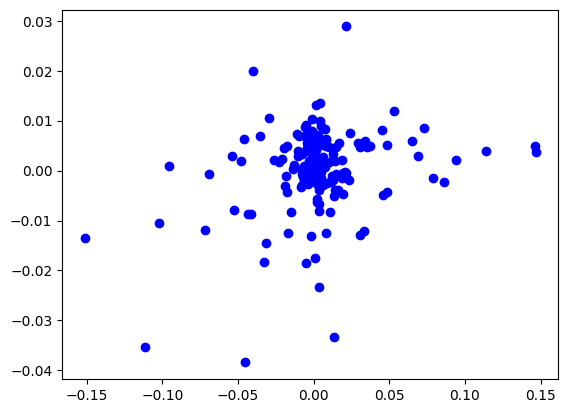

rmse: 0.001183941966994886


In [30]:
plt.scatter(final_gig_m_df['target'], preds, label='residuals', color='blue')
plt.show()
rmse = mean_squared_error(final_gig_m_df['target'], preds)
print(f"rmse: {rmse}")

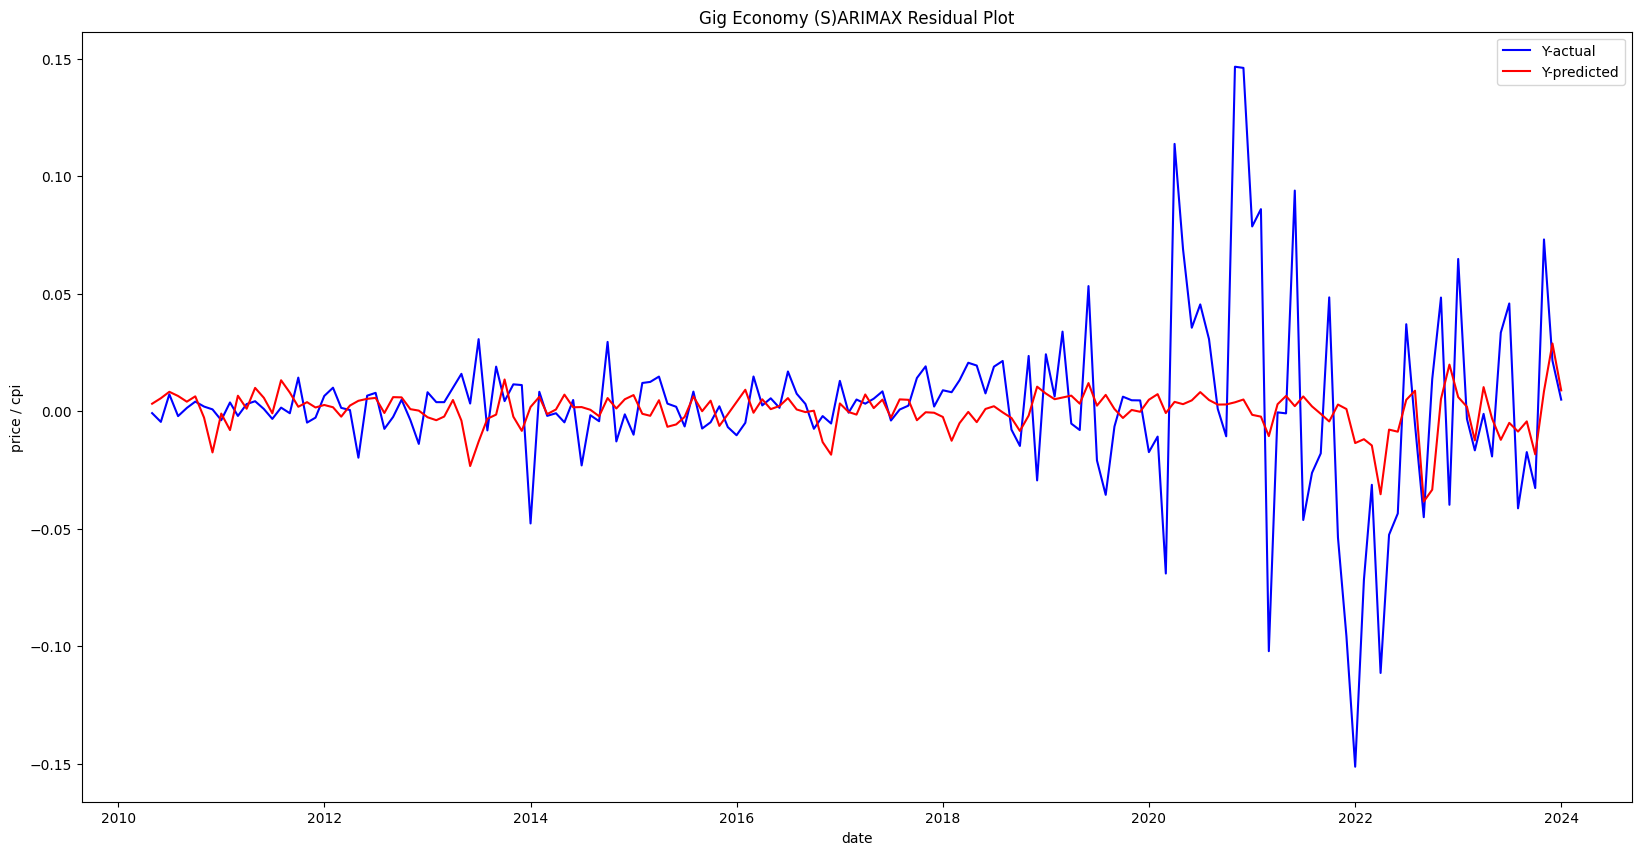

In [31]:
# Create the plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot first line
ax.plot(final_gig_m_df.index, final_gig_m_df['target'], label='Y-actual', color='blue')

# Plot second line
ax.plot(final_gig_m_df.index, preds, label='Y-predicted', color='red')

# Plot 6 sigma
# gig_desc_df = final_gig_m_df.describe()
# mean = gig_desc_df.iloc[1]['target']
# std = gig_desc_df.iloc[2]['target']
# std1 = mean + std
# std_1 = mean - std
# std2 = mean + (std * 2)
# std_2 = mean - (std * 2)
# std3 = mean + (std * 3)
# std_3 = mean - (std * 3)
# ax.axhline(mean, color='purple', linestyle='--', linewidth=2, label='mean')
# ax.axhline(std1, color='purple', linestyle='--', linewidth=2, label='std1')
# ax.axhline(std_1, color='purple', linestyle='--', linewidth=2, label='std-1')
# ax.axhline(std2, color='purple', linestyle='--', linewidth=2, label='std2')
# ax.axhline(std_2, color='purple', linestyle='--', linewidth=2, label='std-2')
# ax.axhline(std3, color='purple', linestyle='--', linewidth=2, label='std3')
# ax.axhline(std_3, color='purple', linestyle='--', linewidth=2, label='std-3')

# ax.xaxis.set_major_locator(mdates.YearLocator())  # Tick every year
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as 'YYYY'

# Add labels and title
plt.xlabel("date")
plt.ylabel("price / cpi")
plt.title("Gig Economy (S)ARIMAX Residual Plot")

# Show legend
plt.legend()

# Display the plot
plt.show()

In [32]:
split_time_in_half = int(len(final_gig_m_df['target'].index)/2)
start_time_index = final_gig_m_df.iloc[0].name
half_way_index = final_gig_m_df.iloc[split_time_in_half].name
end_time_index = final_gig_m_df.iloc[-1].name
before_gig_var = np.var(final_gig_m_df['target'].iloc[:split_time_in_half])
after_gig_var = np.var(final_gig_m_df['target'].iloc[split_time_in_half:])
magnitude_before_after_gig = int(after_gig_var/before_gig_var)
print(f"Gig Economy Variance for two groups.\nGroup 1 starting at {start_time_index} and ending at {half_way_index}: {before_gig_var}\nGroup 2 starting at {half_way_index} and ending at {end_time_index}: {after_gig_var}\nGroup 2 is approximately {magnitude_before_after_gig}x as big as Group 1")

Gig Economy Variance for two groups.
Group 1 starting at 2010-05-01 00:00:00 and ending at 2017-03-01 00:00:00: 0.00011126588520007741
Group 2 starting at 2017-03-01 00:00:00 and ending at 2024-01-01 00:00:00: 0.0024218046363752585
Group 2 is approximately 21x as big as Group 1


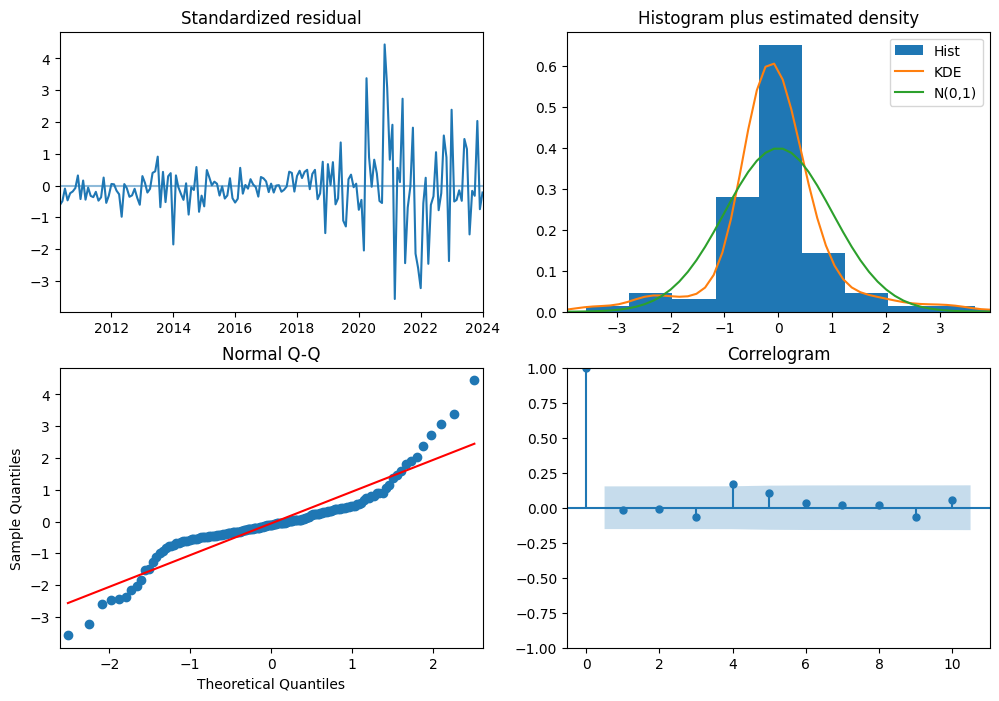

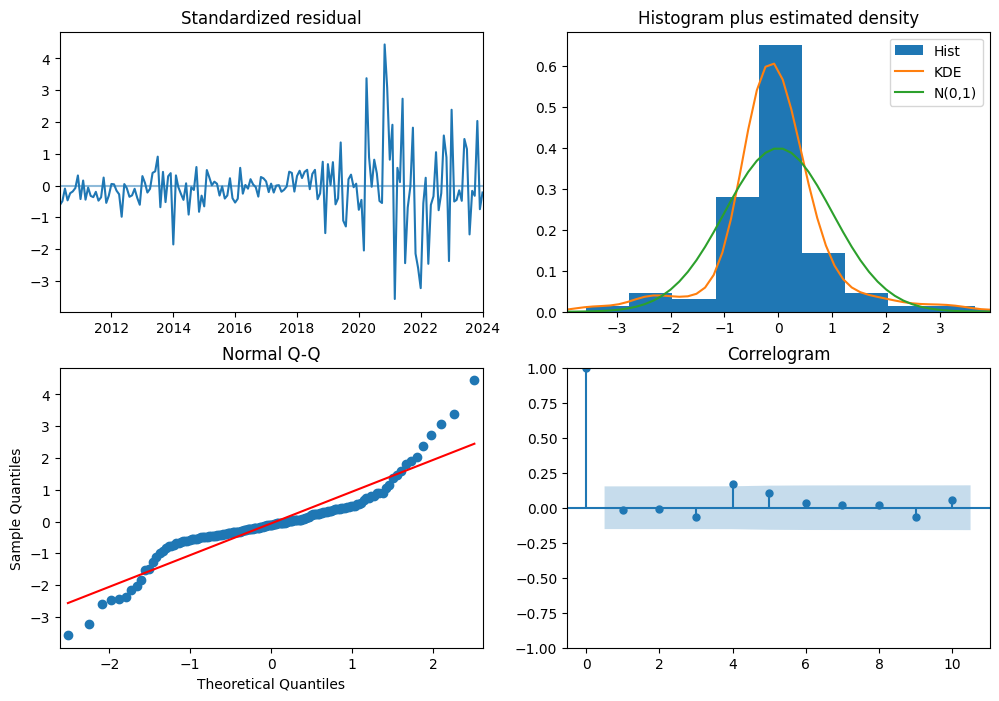

In [33]:
best_gig_model_lst_[best_model_idx][1].plot_diagnostics(figsize=(12, 8))

In [34]:
exog_idx = int(sp500_model_df.iloc[0]['exog_idx'])
best_sp500_model_lst_ = list(best_sp500_model_lst)
for i, _ in enumerate(best_sp500_model_lst_):
    if _[0] == exog_idx:
        best_model_idx = i

preds = best_sp500_model_lst_[best_model_idx][1].predict(len(final_sp500_m_df[exog_cols[exog_idx]]), final_sp500_m_df[exog_cols[exog_idx]])
preds_gig = best_sp500_model_lst_[best_model_idx][1].predict(len(final_gig_m_df[exog_cols[exog_idx]]), final_gig_m_df[exog_cols[exog_idx]])

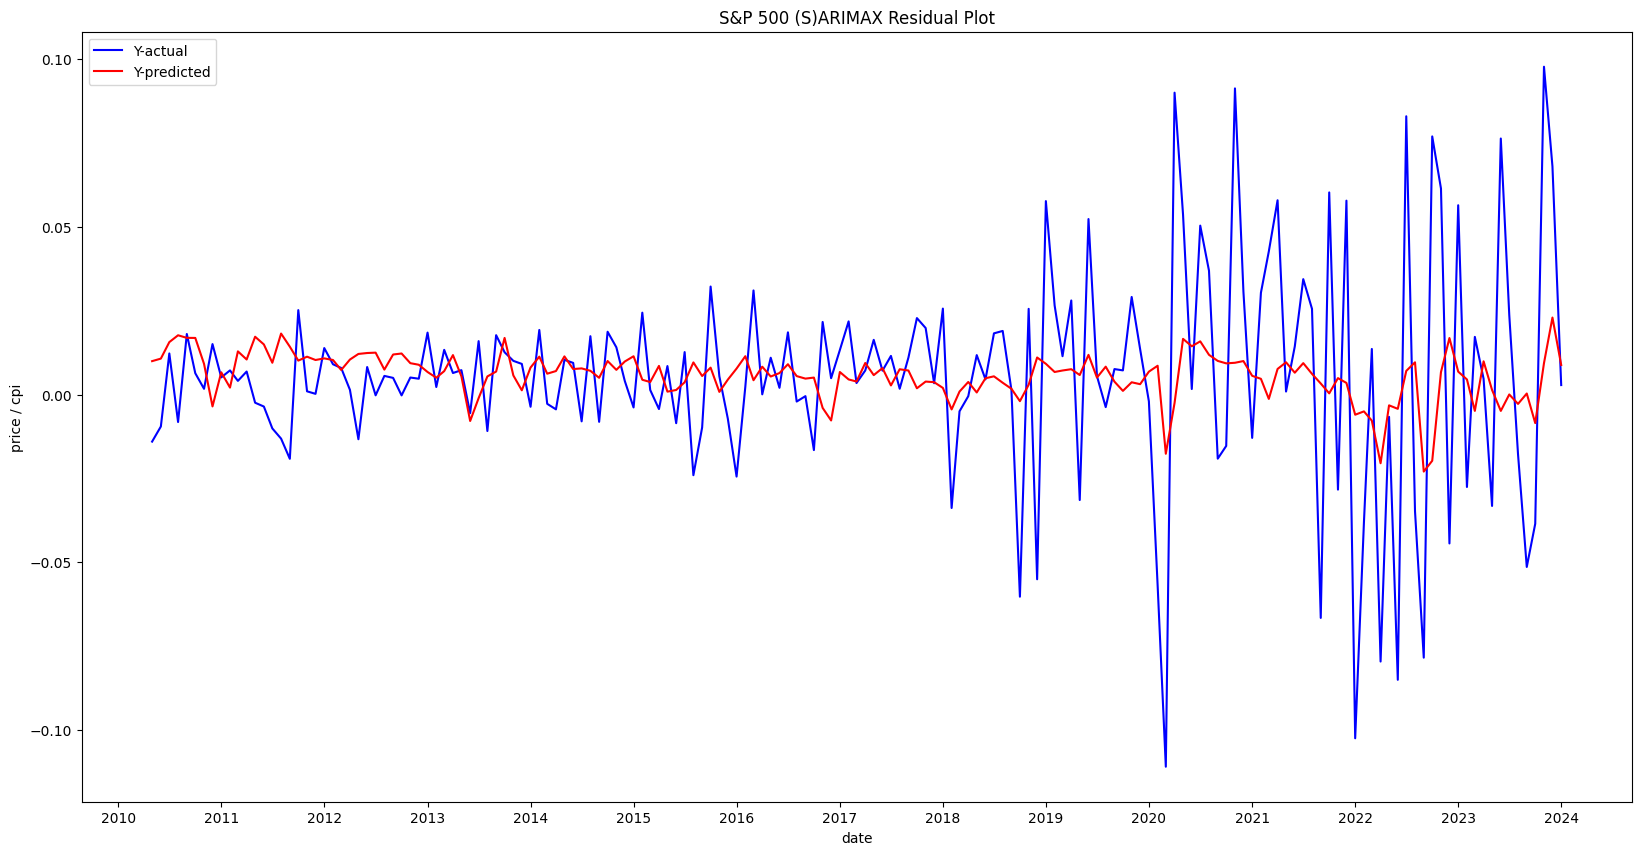

In [35]:
# Create the plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot first line
ax.plot(final_sp500_m_df.index, final_sp500_m_df['target'], label='Y-actual', color='blue')

# Plot second line
ax.plot(final_sp500_m_df.index, preds, label='Y-predicted', color='red')

ax.xaxis.set_major_locator(mdates.YearLocator())  # Tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format ticks as 'YYYY'

# Add labels and title
plt.xlabel("date")
plt.ylabel("price / cpi")
plt.title("S&P 500 (S)ARIMAX Residual Plot")

# Show legend
plt.legend()

# Display the plot
plt.show()

In [36]:
split_time_in_half = int(len(final_sp500_m_df['target'].index)/2)
start_time_index = final_sp500_m_df.iloc[0].name
half_way_index = final_sp500_m_df.iloc[split_time_in_half].name
end_time_index = final_sp500_m_df.iloc[-1].name
before_sp500_var = np.var(final_sp500_m_df['target'].iloc[:split_time_in_half])
after_sp500_var = np.var(final_sp500_m_df['target'].iloc[split_time_in_half:])
magnitude_before_after_sp500 = int(after_sp500_var/before_sp500_var)
print(f"S&P500 Variance for two groups.\nGroup 1 starting at {start_time_index} and ending at {half_way_index}: {before_sp500_var}\nGroup 2 starting at {half_way_index} and ending at {end_time_index}: {after_sp500_var}\nGroup 2 is approximately {magnitude_before_after_sp500}x as big as Group 1")

S&P500 Variance for two groups.
Group 1 starting at 2010-05-01 00:00:00 and ending at 2017-03-01 00:00:00: 0.00013734681780712386
Group 2 starting at 2017-03-01 00:00:00 and ending at 2024-01-01 00:00:00: 0.0019325444051561168
Group 2 is approximately 14x as big as Group 1


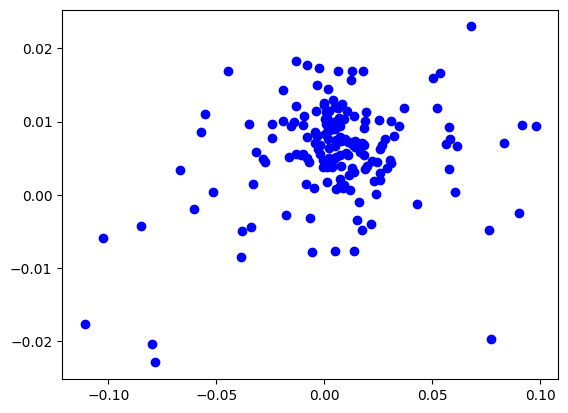

rmse: 0.0009759574013296875


In [37]:
plt.scatter(final_sp500_m_df['target'], preds, label='residuals', color='blue')
plt.show()
rmse = mean_squared_error(final_sp500_m_df['target'], preds)
print(f"rmse: {rmse}")

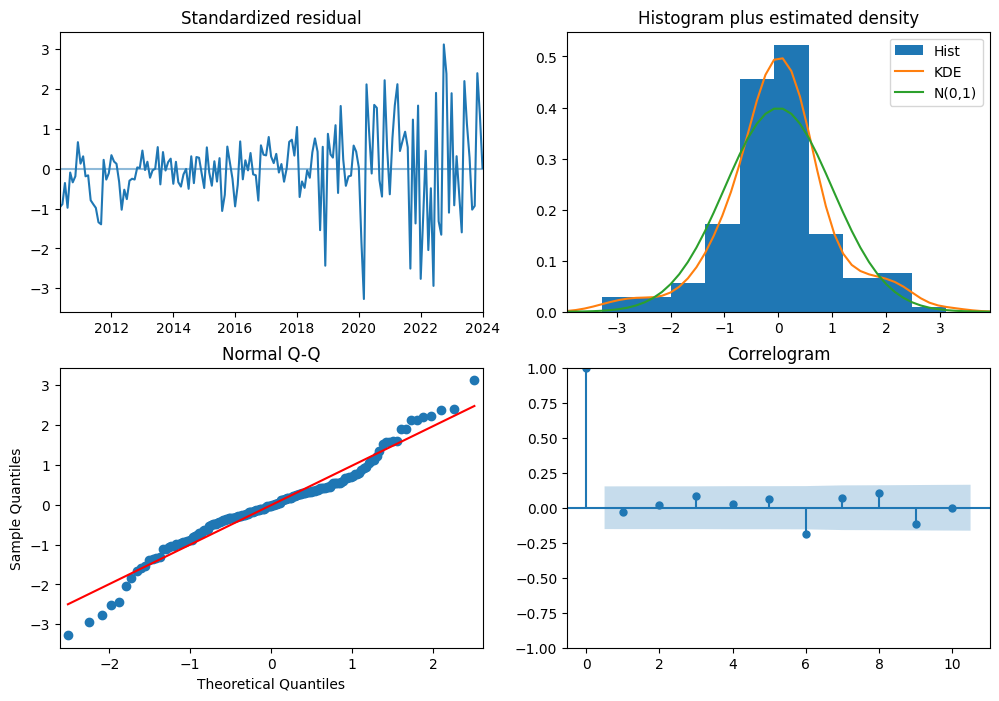

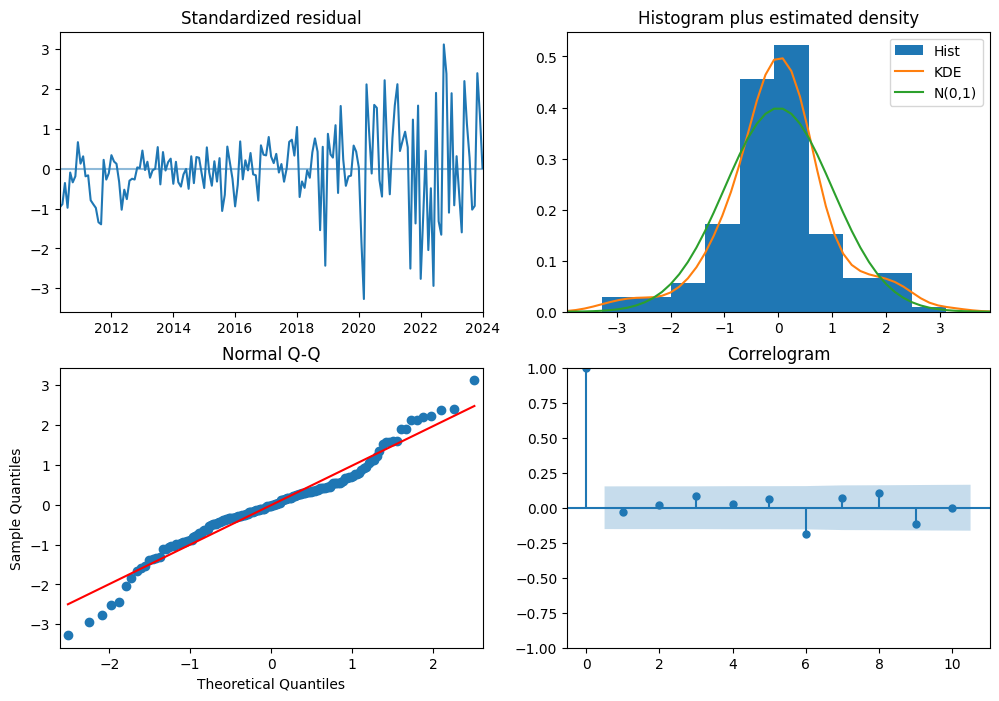

In [38]:
best_sp500_model_lst_[best_model_idx][1].plot_diagnostics(figsize=(12, 8))

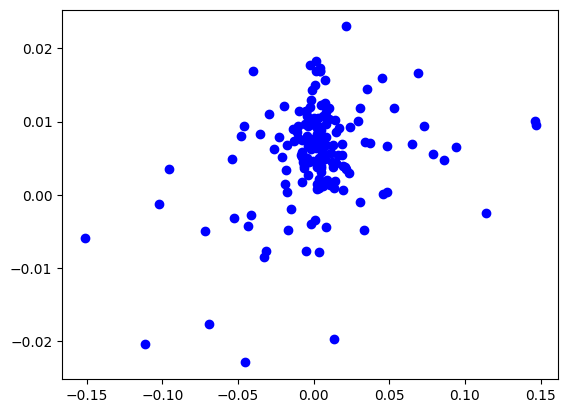

rmse: 0.0011823115897320838


In [39]:
plt.scatter(final_gig_m_df['target'], preds_gig, label='residuals', color='blue')
plt.show()
rmse = mean_squared_error(final_gig_m_df['target'], preds_gig)
print(f"rmse: {rmse}")